# Imports 

In [1]:
import pandas as pd
from collections import defaultdict
import sys
import os
import shutil as sh
import numpy as np
import seaborn as sns
import os
import importlib
import MDAnalysis as mda
import nglview as nv
from biopandas.pdb import PandasPdb
from io import StringIO
import joblib
from sklearn.metrics import average_precision_score


from sklearn.calibration import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, roc_auc_score

from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.spatial import ConvexHull

from urllib.error import HTTPError
from pathlib import Path
from ipywidgets import interact, interactive, fixed, interact_manual, IntProgress
import ipywidgets as widgets # type: ignore
from IPython.display import display, Markdown, clear_output


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [4]:
from functions import IBSClassifier
clf = IBSClassifier(encoding='label', scale=False)

In [5]:
model = RandomForestClassifier(max_depth = 10, min_samples_leaf = 1, min_samples_split = 2, n_estimators = 200)

# Methods

In [7]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.feature_selection import r_regression
from sklearn.impute import SimpleImputer
from sklearn.metrics import matthews_corrcoef
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder



def load_data(path):
    """
    Load data from the path were it was stored.
    """
    if not os.path.isfile(path):
        raise FileNotFoundError(f"The file at {path} was not found.")
    return pd.read_csv(path)

def preprocess_data(df, columns_to_drop=[], categorical_cols=[]):
    """
    Drop uneccessary columns, 
    Encode categorical features, 
    Handle missing values
    """
    encodings: dict[str, np.ndarray] = {}

    # Drop unwanted columns
    if columns_to_drop:
        drop_list = [c for c in columns_to_drop if c in df.columns]
        df = df.drop(columns=drop_list)

    # Label‐encode only the columns listed in categorical_cols
    if categorical_cols:
        for col in categorical_cols:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                encodings[col] = le.classes_.copy()
                

    # Identify numeric columns and build the pipeline
    num_list = df.select_dtypes(include=[np.number]).columns.tolist()

    num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='mean'))])
    df[num_list] = num_pipeline.fit_transform(df[num_list])

    return df, encodings

# def preprocess_data(
#     df: pd.DataFrame,
#     y: pd.Series = None,
#     columns_to_drop: list[str]    = None,
#     categorical_cols: list[str]   = None,
#     encoding: str                 = 'label'
# ) -> tuple[pd.DataFrame, dict]:
#     """
#     1) Drop columns in `columns_to_drop`.
#     2) Encode the columns in `categorical_cols` using the chosen strategy:
#          - 'label'  : sklearn LabelEncoder per-column (maps to 0..n-1)
#          - 'onehot' : sklearn OneHotEncoder (expands to dummies; drop='first' to avoid collinearity)
#          - 'target' : category_encoders.TargetEncoder (requires y, mean-target encode)
#     3) Impute missing values in all numeric columns (mean).
    
#     Returns:
#       - df_transformed: DataFrame after drop, encode, impute
#       - encoders:      dict of fitted encoders (or encoder.attrs if multi-col)
#     """
#     df = df.copy()
#     encoders = {}

#     # 1) Drop
#     if columns_to_drop:
#         to_drop = [c for c in columns_to_drop if c in df.columns]
#         df.drop(columns=to_drop, inplace=True)

#     # 2) Encode
#     if categorical_cols:
#         missing = [c for c in categorical_cols if c not in df.columns]
#         if missing:
#             raise ValueError(f"categorical_cols not in df: {missing}")
        
#         if encoding == 'label':
#             # one LabelEncoder per column
#             for col in categorical_cols:
#                 le = LabelEncoder()
#                 df[col] = le.fit_transform(df[col].astype(str))
#                 encoders[col] = le  # you can inspect le.classes_
        
#         elif encoding == 'onehot':
#         # ColumnTransformer to one-hot the listed columns, drop remainder
#             ohe = OneHotEncoder(
#                  handle_unknown='ignore',
#                 drop='first',
#                 sparse_output=False   # use this instead of sparse=False
#             )
#             ct = ColumnTransformer(
#                  [('ohe', ohe, categorical_cols)],
#                 remainder='drop'
#             )
#             arr = ct.fit_transform(df)
#             cols = ct.get_feature_names_out()
#             df = pd.DataFrame(arr, columns=cols, index=df.index)
#             encoders['onehot'] = ct

#     # 3) Impute numeric
#     num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
#     if num_cols:
#         num_pipe = Pipeline([
#             ('imputer', SimpleImputer(strategy='mean'))
#         ])
#         df[num_cols] = num_pipe.fit_transform(df[num_cols])
#         encoders['imputer'] = num_pipe.named_steps['imputer']

#     return df, encoders

def separate_features_target(df, target, columns_to_remove=None):
    if columns_to_remove is None:
        columns_to_remove=[]
    columns_to_remove=set(columns_to_remove + [target])
    X=df.drop(columns=[col for col in columns_to_remove if col in df.columns])
    y=df[target]
    return X, y


def select_features(X, y, threshold=0.1):
    correlations = pd.Series(r_regression(X, y), index=X.columns)
    selected_features = correlations[correlations.abs() >= threshold].index.tolist()
    print(f"The selected features of {X.shape[1]} were: {len(selected_features)}")
    return selected_features, correlations

def train_tuned_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    cmap="Blues",
    scale=True
):
    """
    Train and evaluate a tuned model using:
      - Confusion matrix (plotted as heatmap)
      - AUC (if applicable)
      - Matthews Correlation Coefficient (MCC)

    Returns:
      auc (float or None), mcc (float), y_test, y_pred
    """
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual: 0", "Actual: 1"],
        columns=["Predicted: 0", "Predicted: 1"]
    )
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap=cmap)
    plt.title(f"{model.__class__.__name__} Confusion Matrix")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

    auc = None
    if hasattr(model, "predict_proba"):
        try:
            y_prob = model.predict_proba(X_test)[:,1]
            auc = roc_auc_score(y_test, y_prob)
            print(f"AUC: {auc:.4f}")
        except Exception:
            print("AUC could not be computed from probabilities.")
    else:
        try:
            auc = roc_auc_score(y_test, y_pred)
            print(f"AUC (label‐based): {auc:.4f}")
        except ValueError:
            print("AUC could not be computed (only one class predicted).")

    
    mcc = matthews_corrcoef(y_test, y_pred)
    print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

    return auc, mcc, y_test, y_pred

# Build Dataset Per Superfamily

In [10]:
df = load_data("/home/user_stel/AISB/Project/dataset/processed_dataset.csv")
# print(df)

In [5]:
groups = { domain_name: sub_df 
           for domain_name, sub_df in df.groupby('domain') }

for domain_name, subset_df in groups.items():
    print(f"Domain: {domain_name}  →  Number of rows: {len(subset_df)}")
    display(subset_df)

Domain: ANNEXIN  →  Number of rows: 9283


,domain,residue_name,IBS,residue_number,convhull_vertex,is_hydrophobic_protrusion,is_co_insertable,exposed,type
157547,ANNEXIN,2.0,1.0,55.0,1.0,0.0,0.0,1.0,4.0
157548,ANNEXIN,2.0,0.0,61.0,1.0,0.0,0.0,1.0,4.0
157549,ANNEXIN,2.0,0.0,68.0,1.0,0.0,0.0,1.0,4.0
157550,ANNEXIN,2.0,1.0,17.0,0.0,0.0,0.0,1.0,4.0
157551,ANNEXIN,2.0,1.0,58.0,1.0,0.0,0.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...
166825,ANNEXIN,4.0,0.0,270.0,1.0,1.0,0.0,1.0,1.0
166826,ANNEXIN,4.0,0.0,262.0,1.0,1.0,0.0,1.0,1.0
166827,ANNEXIN,4.0,0.0,243.0,1.0,1.0,0.0,1.0,1.0
166828,ANNEXIN,4.0,0.0,242.0,1.0,1.0,0.0,1.0,1.0


Domain: C1  →  Number of rows: 2088


,domain,residue_name,IBS,residue_number,convhull_vertex,is_hydrophobic_protrusion,is_co_insertable,exposed,type
79083,C1,2.0,0.0,156.0,1.0,0.0,0.0,1.0,4.0
79084,C1,2.0,0.0,154.0,0.0,0.0,0.0,1.0,4.0
79085,C1,2.0,0.0,175.0,1.0,0.0,0.0,1.0,4.0
79086,C1,2.0,0.0,199.0,1.0,0.0,0.0,1.0,4.0
79087,C1,2.0,0.0,204.0,1.0,0.0,0.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...
81166,C1,4.0,0.0,79.0,0.0,0.0,0.0,0.0,1.0
81167,C1,4.0,0.0,21.0,1.0,1.0,0.0,1.0,1.0
81168,C1,4.0,1.0,274.0,0.0,0.0,0.0,1.0,1.0
81169,C1,4.0,1.0,268.0,0.0,0.0,0.0,1.0,1.0


Domain: C2  →  Number of rows: 15199


...

,domain,residue_name,IBS,residue_number,convhull_vertex,is_hydrophobic_protrusion,is_co_insertable,exposed,type
139085,PLD,2.0,0.0,319.0,0.0,0.0,0.0,0.0,4.0
139086,PLD,2.0,0.0,324.0,0.0,0.0,0.0,0.0,4.0
139087,PLD,2.0,0.0,328.0,0.0,0.0,0.0,0.0,4.0
139088,PLD,2.0,0.0,409.0,0.0,0.0,0.0,0.0,4.0
139089,PLD,2.0,0.0,462.0,0.0,0.0,0.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...
157542,PLD,4.0,0.0,185.0,0.0,0.0,0.0,0.0,1.0
157543,PLD,4.0,0.0,231.0,0.0,0.0,0.0,0.0,1.0
157544,PLD,4.0,0.0,233.0,0.0,0.0,0.0,0.0,1.0
157545,PLD,4.0,0.0,16.0,0.0,0.0,0.0,0.0,1.0


Domain: PX  →  Number of rows: 5847


,domain,residue_name,IBS,residue_number,convhull_vertex,is_hydrophobic_protrusion,is_co_insertable,exposed,type
133238,PX,2.0,0.0,27.0,1.0,0.0,0.0,1.0,4.0
133239,PX,2.0,0.0,11.0,1.0,0.0,0.0,1.0,4.0
133240,PX,2.0,0.0,9.0,0.0,0.0,0.0,1.0,4.0
133241,PX,2.0,0.0,26.0,0.0,0.0,0.0,1.0,4.0
133242,PX,2.0,0.0,26.0,0.0,0.0,0.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...
139080,PX,4.0,0.0,138.0,0.0,0.0,0.0,0.0,1.0
139081,PX,4.0,0.0,133.0,0.0,0.0,0.0,0.0,1.0
139082,PX,4.0,0.0,133.0,0.0,0.0,0.0,0.0,1.0
139083,PX,4.0,0.0,41.0,0.0,0.0,0.0,0.0,1.0


Domain: START  →  Number of rows: 32393


,domain,residue_name,IBS,residue_number,convhull_vertex,is_hydrophobic_protrusion,is_co_insertable,exposed,type
46690,START,2.0,0.0,79.0,1.0,0.0,0.0,1.0,4.0
46691,START,2.0,0.0,95.0,0.0,0.0,0.0,0.0,4.0
46692,START,2.0,1.0,129.0,0.0,0.0,0.0,0.0,4.0
46693,START,2.0,0.0,154.0,0.0,0.0,0.0,0.0,4.0
46694,START,2.0,0.0,15.0,1.0,0.0,0.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...
79078,START,4.0,0.0,207.0,0.0,0.0,0.0,0.0,1.0
79079,START,4.0,0.0,207.0,0.0,0.0,0.0,0.0,1.0
79080,START,4.0,0.0,207.0,0.0,0.0,0.0,0.0,1.0
79081,START,4.0,0.0,207.0,0.0,0.0,0.0,0.0,1.0


In [6]:
for domain_name, subset_df in groups.items():
    filename = f"{domain_name}_subset.csv"
    subset_df.to_csv(filename, index=False)


## Palette & Configuration

In [6]:
reverse_type = {
     0: "Hydrophobic,H-aromatic",
     1: "Hydrophobic,H-non-aromatic",
     2: "Negative",
     3: "Non-polar",
     4: "Polar",
     5: "Positive"
}

# For the residue_name three‐letter codes:
reverse_residue = {
    0:  "ALA",  1:  "ARG",  2:  "ASN",  3:  "ASP",  4:  "CYS",
    5:  "GLN",  6:  "GLU",  7:  "GLY",  8:  "HIS",  9:  "ILE",
    10: "LEU", 11:  "LYS", 12:  "MET", 13:  "PHE", 14:  "PRO",
    15: "SER", 16:  "THR", 17:  "TRP", 18:  "TYR", 19:  "VAL"
}

In [7]:
dict_palette_IBS = {"IBS":"#A5CCE2",'nonIBS':"#DFA3AE"}
palette_IBS = [dict_palette_IBS["nonIBS"],dict_palette_IBS["IBS"]]
DPI=300
FORMAT="tif"
sns.set_style("whitegrid") #Seaborn style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams["font.family"] = "Arial" 


def get_palette_OR(oddsratio):
    palette = []
    for index, row in oddsratio.iterrows():
        if row["pvalue"] < 0.05:
            if row.oddsratio > 0:
                palette.append(dict_palette_IBS["IBS"])
            else:
                palette.append(dict_palette_IBS["nonIBS"])
        else:
            palette.append("gray")
    return(palette)

def significance(ortable):
    def add_symbol(row):
        if row.pvalue > 0.05:
            return "ns"
        elif row.pvalue <= 0.0001:
            return '****'
        elif row.pvalue <= 0.001:
            return '***'
        elif row.pvalue <= 0.01:
            return '**'
        elif row.pvalue <= 0.05:
            return '*'
        else:
            return 'NA'
        
    ortable["significance"] = ortable.apply(lambda x: add_symbol(x), axis=1)
    ortable["labels"] ="("+ortable["significance"]+") " + ortable.iloc[:,0].astype(str)
    return ortable

def equality_test(pop1,pop2, ALTERNATIVE="two-sided", pairwised=False, silent=False, returnPval=False):
    """
    Perform equality test between two sample
    
    Args:
        - pop1 (array): sample1 (continuous or discrete data)
        - pop2 (array): sample2 (continuous or discrete data)
        - ALTERNATIVE (str): could be 'two-sided','less','greater'. Default is 'two-sided'
    Teturn:
        None
    """
        
    #for formating
    from IPython.display import Markdown, display
    def printmd(string, color=None):
        colorstr = "<span style='color:{}'>{}</span>".format(color, string)
        if not silent:
            display(Markdown(colorstr))
        
    printmd("**STATISTICAL TEST BETWEEN TWO SAMPLES**")
    
    printmd(f" - ALTERNATIVE HYPOTHESIS = {ALTERNATIVE}")
    from decimal import Decimal
    import scipy.stats as stats
    
    sign = {"two-sided":"≠",
       "less":"<",
       "greater":">"}
    

    printmd("**NORMALITY TEST (shapiro)**")
    normality = True
    printmd("*The two samples should follow a normal law to use a standard t.test*")

    normpop1 = stats.shapiro(pop1).pvalue
    normpop2 = stats.shapiro(pop2).pvalue
    if normpop1 < 0.05:
        printmd(f"---- Sample 1 shapioro test pvalue = {normpop1:.2E}, <= 0.05. This sample DO NOT follow a normal law", color='red')
        normality = False
    else: 
        printmd(f"---- Sample 1 shapioro test pvalue = {normpop1:.2E}, > 0.05. This sample follow a normal law", color='blue')
    if normpop2 < 0.05:
        printmd(f"---- Sample 1 shapioro test pvalue = {normpop2:.2E}, <= 0.05. This sample DO NOT follow a normal law", color='red')
        normality = False
    else: 
        printmd(f"---- Sample 1 shapioro test pvalue = {normpop2:.2E}, > 0.05. This sample follow a normal law", color='blue')

    if normality == True:
        printmd("Both samples follow a normal law")

        if pairwised == True:
            printmd("**TTest_REL Pairwise test **")
            equalstat, equalpval = stats.ttest_rel(pop1,pop2)
            if returnPval:
                return equalpval
        else: 
            printmd("Performing Variance equality test")
            varstat, varpval = stats.levene(pop1,pop2)
            #Levene, pval < 0.05 --> Variance are not equal.
            #Levene, pval > 0.05 --> Non significatif and the hypothesis H0 is not rejected. 


            printmd("-- Null hypothesis, the the variances are equals")
            printmd(f"---- Variance test --> stat={varstat:.2E}, p-value={varpval:.3E}")
            if varpval < 0.05:
                printmd("P value <= 0.05, H0 rejected. the variance are not equal. Performing Welch’s t-test", color="red")
                equal_var = False
            else:
                printmd("Pvalue > 0.05, the variances not equal. Performing a standard independent 2 sample test ", color="blue")
                equal_var = True
            equalstat, equalpval = stats.ttest_ind(pop1,
                                       pop2,
                                       equal_var=equal_var,)
            
        printmd(f"t-test --> stat={equalstat:.2E}, p-value={equalpval:.3E}")
        printmd(f"  Null hypothesis : the two samples average are equal")
        printmd(f"  Alternative hypothesis : average(sample2) {sign[ALTERNATIVE]} average(sample2)")
        if equalpval > 0.05:
            printmd("pvalue > 0.05, we cannot reject the null hypothesis of identical average between both populations.", color="blue")
        else:
            printmd("pvalue <= 0.05, the null hypothesis is rejected, the two samples are differents", color="red")
    else:
        printmd("One or both sample(s) doesn't follow a normal law.")
        if pairwised==True:
            printmd("**WILCOXON SIGNED-RANK TEST**")
            printmd(f"  Null hypothesis : the two distribution are equals")
            printmd(f"  Alternative hypothesis : pop1 {sign[ALTERNATIVE]} pop2")
            stat, pval = stats.wilcoxon(pop1,pop2, alternative=ALTERNATIVE)
        else:
            printmd("Performing a Wilcoxon Rank sum test with continuity correction")
            printmd("**WILCOXON RANK SUM TEST WITH CONTINUITY CORRECTION (or Mann-Whitney test)**")
            printmd(f"  Null hypothesis : the two distribution are equals")
            printmd(f"  Alternative hypothesis : pop1 {sign[ALTERNATIVE]} pop2")
            stat, pval = stats.mannwhitneyu(pop1,pop2, alternative=ALTERNATIVE)
        if pval < 0.05:
            printmd(f"  pvalue = {pval:.2E} which is <= 0.05. The null hypothesis is rejected. The alternative hypothesis (f{ALTERNATIVE}) is valid and the two distrubition are different", color="red")
        else:
            printmd(f"  pvalue = {pval:.2E} which is > 0.05. The null hypothesis not rejected. Both distributions are not statistically differents.", color="blue")
        if returnPval:
            return pval


#COLORS
colorsPerType = {"Positive":"tab:blue",
         "Negative":"tab:red",
         "Non-polar":"tab:gray",
         "Hydrophobic,H-non-aromatic":"tab:brown",
         "Hydrophobic,H-aromatic":"tab:pink",
         "Polar":"tab:green"}
AATYPE = {
    "LEU": "Hydrophobic,H-non-aromatic",
    "ILE": "Hydrophobic,H-non-aromatic",
    "CYS": "Hydrophobic,H-non-aromatic",
    "MET": "Hydrophobic,H-non-aromatic",
    "TYR": "Hydrophobic,H-aromatic",
    "TRP": "Hydrophobic,H-aromatic",
    "PHE": "Hydrophobic,H-aromatic",
    "HIS": "Polar",
    "LYS": "Positive",
    "ARG": "Positive",
    "ASP": "Negative",
    "GLU": "Negative",
    "VAL": "Non-polar",
    "ALA": "Non-polar",
    "SER": "Polar",
    "ASN": "Polar",
    "GLY": "Non-polar",
    "PRO": "Non-polar",
    "GLN": "Polar",
    "THR": "Polar",
    "UNK": "none"
}


#From http://acces.ens-lyon.fr/biotic/rastop/help/colour.htm#shapelycolours
COLORS_taylor = {
    "LEU": "#33FF00",
    "ILE": "#66FF00",
    "CYS": "#FFFF00",
    "MET": "#00FF00",
    "TYR": "#00FFCC",
    "TRP": "#00CCFF",
    "PHE": "#00FF66",
    "HIS": "#0066FF",
    "LYS": "#6600FF",
    "ARG": "#0000FF",
    "ASP": "#FF0000",
    "GLU": "#FF0066",
    "VAL": "#99FF00",
    "ALA": "#CCFF00",
    "GLY": "#FF9900",
    "PRO": "#FFCC00",
    "SER": "#FF3300",
    "ASN": "#CC00FF",
    "GLN": "#FF00CC",
    "THR": "#FF6600",
    "UNK": "#000000"
}

## ANNEXIN 

In [8]:
path_to_annexin = '/home/user_stel/AISB/Project/dataset/ANNEXIN_subset.csv'
annexin_df = clf.load_data(path_to_annexin)

columns_to_remove = ['domain', 'residue_number']
X, y = clf.separate_features_target(annexin_df, target='IBS', columns_to_remove=columns_to_remove)

[Run 1] AUC: 0.7719, PR AUC: 0.4775, MCC: 0.3168
  ↳ New best model (AUC=0.7719)
[Run 2] AUC: 0.7948, PR AUC: 0.5139, MCC: 0.3189
  ↳ New best model (AUC=0.7948)
[Run 3] AUC: 0.7910, PR AUC: 0.5043, MCC: 0.3110
[Run 4] AUC: 0.7775, PR AUC: 0.4869, MCC: 0.3102
[Run 5] AUC: 0.7946, PR AUC: 0.5225, MCC: 0.3318
[Run 6] AUC: 0.7791, PR AUC: 0.5067, MCC: 0.3143
[Run 7] AUC: 0.7900, PR AUC: 0.4996, MCC: 0.3235
[Run 8] AUC: 0.8012, PR AUC: 0.5102, MCC: 0.3010
  ↳ New best model (AUC=0.8012)
[Run 9] AUC: 0.7832, PR AUC: 0.4886, MCC: 0.2838
[Run 10] AUC: 0.7834, PR AUC: 0.4865, MCC: 0.2978
[Run 11] AUC: 0.7916, PR AUC: 0.5138, MCC: 0.3254
[Run 12] AUC: 0.7673, PR AUC: 0.4717, MCC: 0.2996
[Run 13] AUC: 0.7793, PR AUC: 0.5058, MCC: 0.3052
[Run 14] AUC: 0.8195, PR AUC: 0.5545, MCC: 0.3627
  ↳ New best model (AUC=0.8195)
[Run 15] AUC: 0.7932, PR AUC: 0.4860, MCC: 0.2828
[Run 16] AUC: 0.7996, PR AUC: 0.5258, MCC: 0.3291
[Run 17] AUC: 0.7921, PR AUC: 0.5208, MCC: 0.3454
[Run 18] AUC: 0.7888, PR AUC: 0

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


[Run 30] AUC: 0.7894, PR AUC: 0.4998, MCC: 0.3168


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

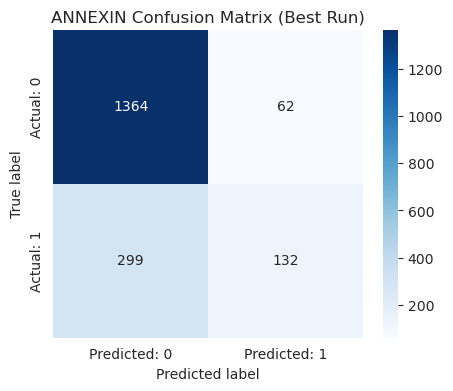

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

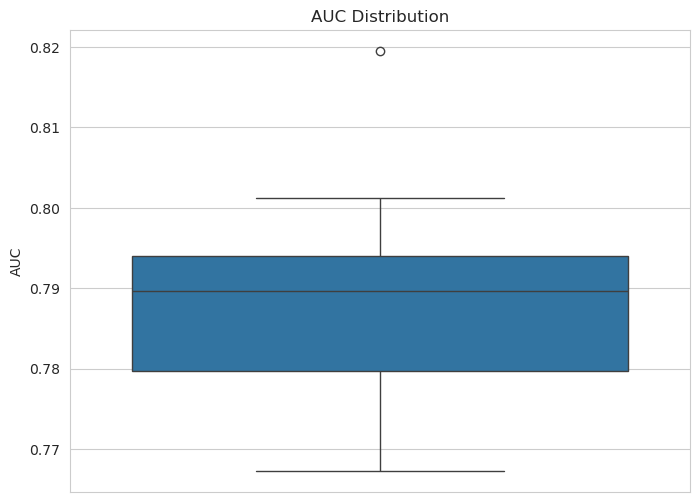

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


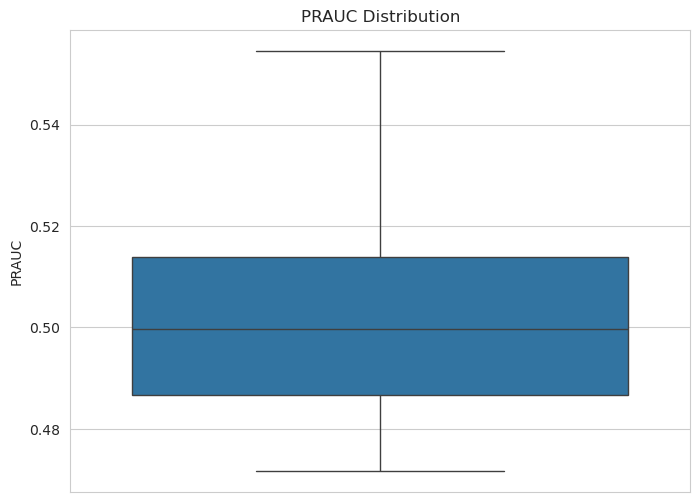

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

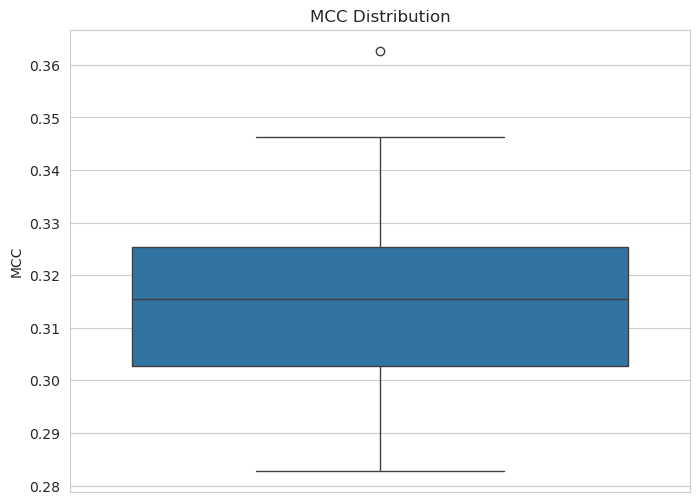

In [9]:
annexin_results, y_test, y_pred, X_test = clf.evaluate_model(model, X, y, runs=30, test_size=0.2, subset_name='ANNEXIN', save_path=None, cmap="Blues")

In [ ]:
# Build predicted dataset for ANNEXIN 
df_pred_annexin = X_test.copy()

df_pred_annexin['residue_str'] = df_pred_annexin['residue_name'].map(reverse_residue)
df_pred_annexin['type_str']    = df_pred_annexin['type'].map(reverse_type)
df_pred_annexin['IBS_pred']    = y_pred
df_pred_annexin['exposed']     = X_test['exposed']   

#print(df_pred_annexin.head())
df_pred_annexin.to_csv("/home/user_stel/AISB/Project/dataset/predicted /ANNEXIN_pred.csv", index=False)

## C1

In [11]:
path_to_c1 = '/home/user_stel/AISB/Project/dataset/C1_subset.csv'
c1_df = clf.load_data(path_to_c1)

columns_to_remove = ['domain', 'residue_number']
X, y = clf.separate_features_target(c1_df, target='IBS', columns_to_remove=columns_to_remove)

[Run 1] AUC: 0.8131, PR AUC: 0.4889, MCC: 0.2883
  ↳ New best model (AUC=0.8131)
[Run 2] AUC: 0.7822, PR AUC: 0.4526, MCC: 0.2639
[Run 3] AUC: 0.8003, PR AUC: 0.4729, MCC: 0.3327
[Run 4] AUC: 0.7733, PR AUC: 0.4650, MCC: 0.3245
[Run 5] AUC: 0.7430, PR AUC: 0.3953, MCC: 0.2291
[Run 6] AUC: 0.8232, PR AUC: 0.5028, MCC: 0.3061
  ↳ New best model (AUC=0.8232)
[Run 7] AUC: 0.7913, PR AUC: 0.5034, MCC: 0.3152
[Run 8] AUC: 0.7963, PR AUC: 0.5035, MCC: 0.3761
[Run 9] AUC: 0.8031, PR AUC: 0.5115, MCC: 0.3255
[Run 10] AUC: 0.7415, PR AUC: 0.4242, MCC: 0.2422
[Run 11] AUC: 0.7397, PR AUC: 0.4398, MCC: 0.3073
[Run 12] AUC: 0.7399, PR AUC: 0.4773, MCC: 0.3789
[Run 13] AUC: 0.7971, PR AUC: 0.5212, MCC: 0.4104
[Run 14] AUC: 0.7624, PR AUC: 0.4409, MCC: 0.3152
[Run 15] AUC: 0.7774, PR AUC: 0.4910, MCC: 0.3717
[Run 16] AUC: 0.7913, PR AUC: 0.4987, MCC: 0.3660
[Run 17] AUC: 0.8366, PR AUC: 0.5198, MCC: 0.3562
  ↳ New best model (AUC=0.8366)
[Run 18] AUC: 0.7828, PR AUC: 0.4528, MCC: 0.2968
[Run 19] AUC:

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[Run 30] AUC: 0.7995, PR AUC: 0.4657, MCC: 0.3014


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

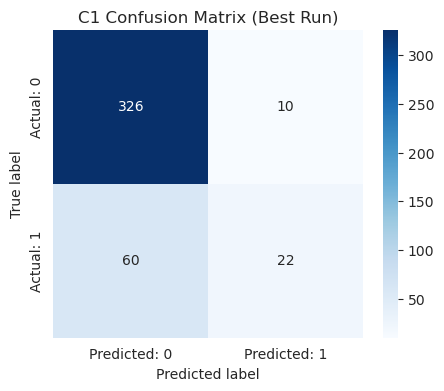

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

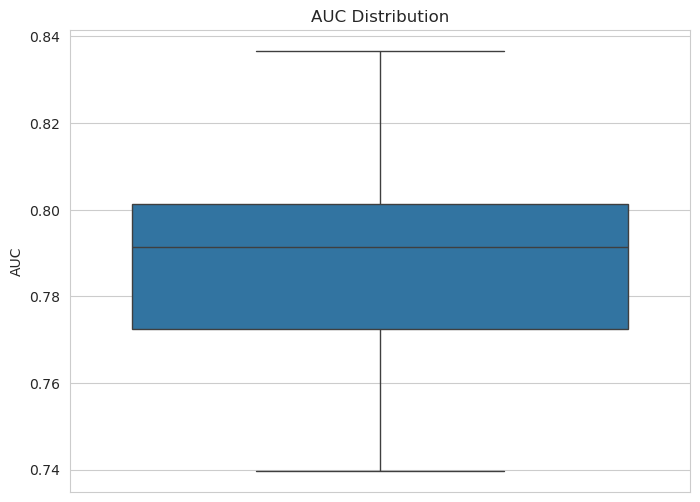

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

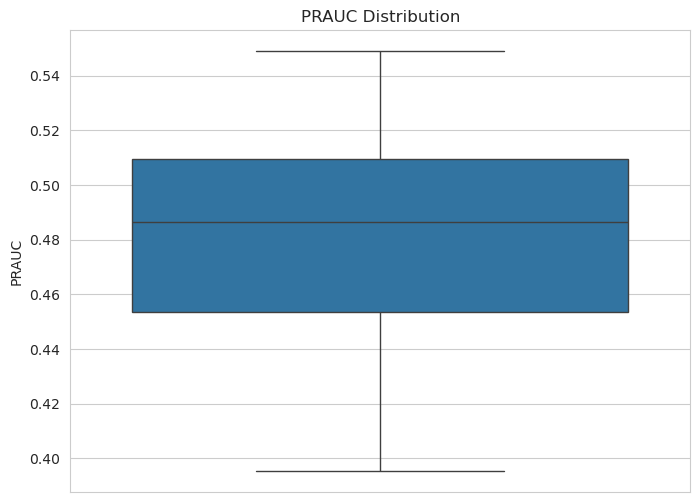

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

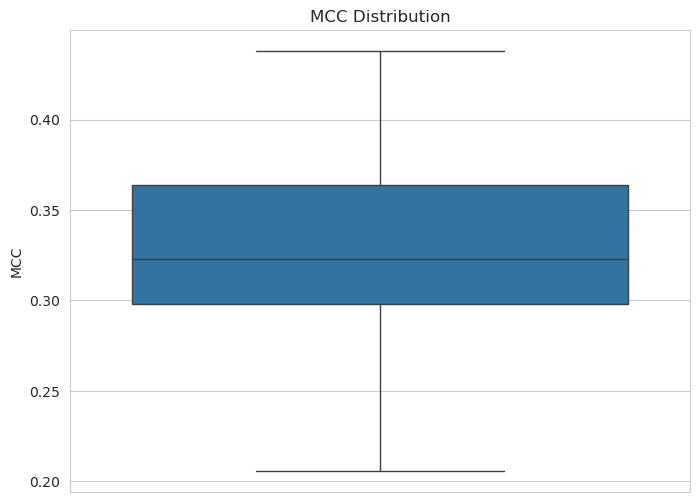

In [12]:
c1_results, y_test, y_pred, X_test = clf.evaluate_model(model, X, y, runs=30, test_size=0.2, subset_name='C1', save_path=None, cmap="Blues")

In [ ]:
# Build predicted dataset for C1 
df_pred_c1 = X_test.copy()

df_pred_c1['residue_str'] = df_pred_c1['residue_name'].map(reverse_residue)
df_pred_c1['type_str']    = df_pred_c1['type'].map(reverse_type)
df_pred_c1['IBS_pred']    = y_pred
df_pred_c1['exposed']     = X_test['exposed']   

#print(df_pred_c1.head())
df_pred_c1.to_csv("/home/user_stel/AISB/Project/dataset/predicted /C1_pred.csv", index=False)

## C2

In [14]:
path_to_c2 = '/home/user_stel/AISB/Project/dataset/C2_subset.csv'
c2_df = clf.load_data(path_to_c2)

columns_to_remove = ['domain', 'residue_number']
X, y = clf.separate_features_target(c2_df, target='IBS', columns_to_remove=columns_to_remove)

[Run 1] AUC: 0.7541, PR AUC: 0.2780, MCC: 0.1783
  ↳ New best model (AUC=0.7541)
[Run 2] AUC: 0.7820, PR AUC: 0.3141, MCC: 0.1103
  ↳ New best model (AUC=0.7820)
[Run 3] AUC: 0.7704, PR AUC: 0.3054, MCC: 0.0753
[Run 4] AUC: 0.7537, PR AUC: 0.2748, MCC: 0.1574
[Run 5] AUC: 0.7714, PR AUC: 0.2972, MCC: 0.1718
[Run 6] AUC: 0.7687, PR AUC: 0.3109, MCC: 0.1080
[Run 7] AUC: 0.7746, PR AUC: 0.3052, MCC: 0.0368
[Run 8] AUC: 0.7799, PR AUC: 0.3059, MCC: 0.1153
[Run 9] AUC: 0.7434, PR AUC: 0.2719, MCC: 0.1645
[Run 10] AUC: 0.7751, PR AUC: 0.3157, MCC: 0.1019
[Run 11] AUC: 0.7675, PR AUC: 0.3147, MCC: 0.1019
[Run 12] AUC: 0.7643, PR AUC: 0.2967, MCC: 0.1153
[Run 13] AUC: 0.7633, PR AUC: 0.2887, MCC: 0.1690
[Run 14] AUC: 0.7733, PR AUC: 0.3134, MCC: 0.0965
[Run 15] AUC: 0.7576, PR AUC: 0.2822, MCC: 0.1013
[Run 16] AUC: 0.7649, PR AUC: 0.2765, MCC: 0.1531
[Run 17] AUC: 0.7845, PR AUC: 0.3087, MCC: 0.1710
  ↳ New best model (AUC=0.7845)
[Run 18] AUC: 0.7682, PR AUC: 0.2818, MCC: 0.1525
[Run 19] AUC:

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[Run 30] AUC: 0.7650, PR AUC: 0.2947, MCC: 0.1601


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

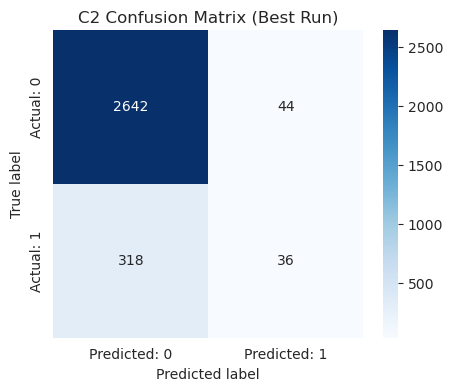

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


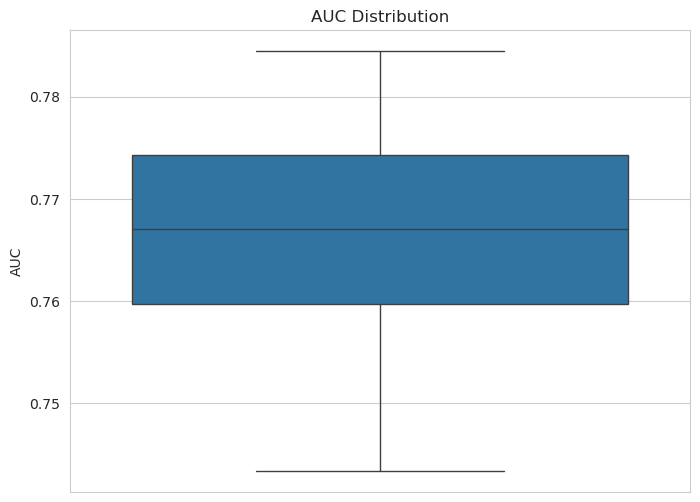

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

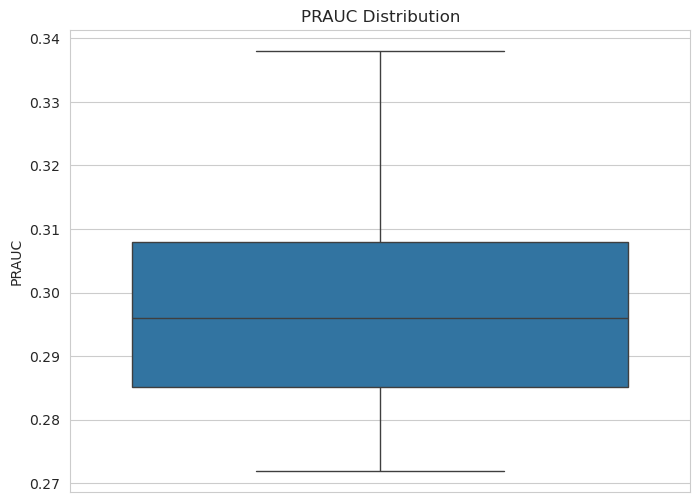

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

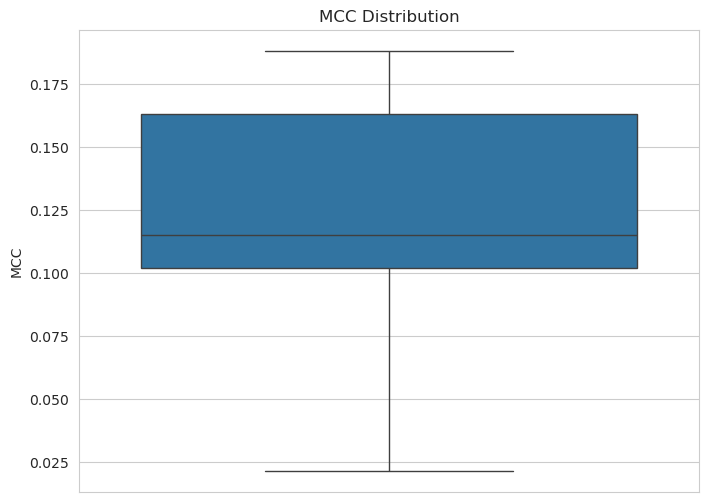

In [15]:
c2_results, y_test, y_pred, X_test = clf.evaluate_model(model, X, y, runs=30, test_size=0.2, subset_name='C2', save_path=None, cmap="Blues")

In [ ]:
# Build predicted dataset for C2 
df_pred_c2 = X_test.copy()

df_pred_c2['residue_str'] = df_pred_c2['residue_name'].map(reverse_residue)
df_pred_c2['type_str']    = df_pred_c2['type'].map(reverse_type)
df_pred_c2['IBS_pred']    = y_pred
df_pred_c2['exposed']     = X_test['exposed']   

df_pred_c2.to_csv("/home/user_stel/AISB/Project/dataset/predicted /C2_pred.csv", index=False)

## C2DIS

In [17]:
path_to_c2dis = '/home/user_stel/AISB/Project/dataset/C2DIS_subset.csv'
c2dis_df = clf.load_data(path_to_c2)

columns_to_remove = ['domain', 'residue_number']
X, y = clf.separate_features_target(c2dis_df, target='IBS', columns_to_remove=columns_to_remove)

[Run 1] AUC: 0.7901, PR AUC: 0.3284, MCC: 0.1274
  ↳ New best model (AUC=0.7901)
[Run 2] AUC: 0.7721, PR AUC: 0.2969, MCC: 0.0915
[Run 3] AUC: 0.7820, PR AUC: 0.3166, MCC: 0.0935
[Run 4] AUC: 0.7585, PR AUC: 0.2744, MCC: 0.1519
[Run 5] AUC: 0.7736, PR AUC: 0.3084, MCC: 0.0866
[Run 6] AUC: 0.7625, PR AUC: 0.2934, MCC: 0.1921
[Run 7] AUC: 0.7588, PR AUC: 0.3128, MCC: 0.0635
[Run 8] AUC: 0.7643, PR AUC: 0.2961, MCC: 0.1611
[Run 9] AUC: 0.7686, PR AUC: 0.2880, MCC: 0.1620
[Run 10] AUC: 0.7476, PR AUC: 0.3013, MCC: 0.1274
[Run 11] AUC: 0.7669, PR AUC: 0.3091, MCC: 0.1945
[Run 12] AUC: 0.7794, PR AUC: 0.3245, MCC: 0.0919
[Run 13] AUC: 0.7730, PR AUC: 0.2897, MCC: 0.1599
[Run 14] AUC: 0.7712, PR AUC: 0.2945, MCC: 0.1690
[Run 15] AUC: 0.7712, PR AUC: 0.2918, MCC: 0.1241
[Run 16] AUC: 0.7661, PR AUC: 0.2809, MCC: 0.1277
[Run 17] AUC: 0.7551, PR AUC: 0.2733, MCC: 0.1419
[Run 18] AUC: 0.7760, PR AUC: 0.3061, MCC: 0.0870
[Run 19] AUC: 0.7732, PR AUC: 0.2982, MCC: 0.0359
[Run 20] AUC: 0.7747, PR AU

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[Run 30] AUC: 0.7590, PR AUC: 0.2957, MCC: 0.1103


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


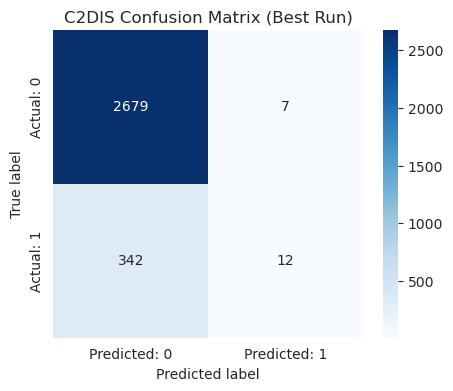

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

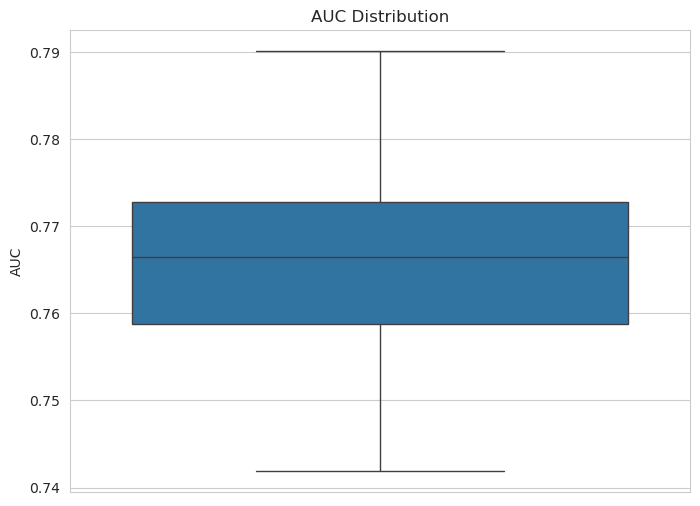

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

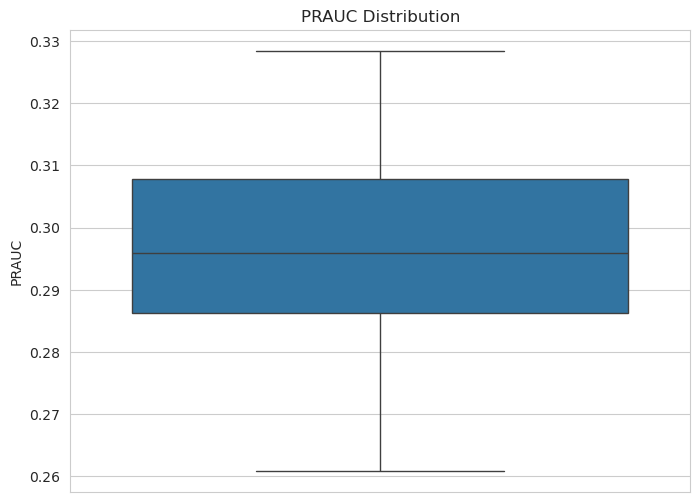

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

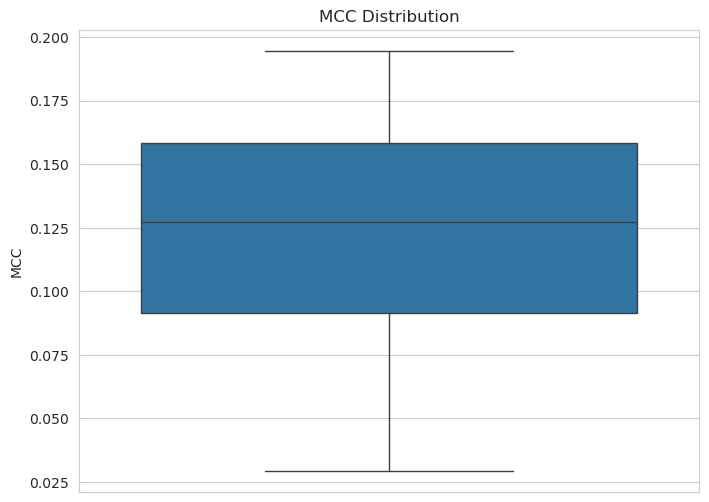

In [18]:
c2dis_results, y_test, y_pred, X_test = clf.evaluate_model(model, X, y, runs=30, test_size=0.2, subset_name='C2DIS', save_path=None, cmap="Blues")

In [19]:
# Build predicted dataset for C2DIS 
df_pred_c2dis = X_test.copy()

df_pred_c2dis['residue_str'] = df_pred_c2dis['residue_name'].map(reverse_residue)
df_pred_c2dis['type_str']    = df_pred_c2dis['type'].map(reverse_type)
df_pred_c2dis['IBS_pred']    = y_pred
df_pred_c2dis['exposed']     = X_test['exposed']

df_pred_c2dis.to_csv("/home/user_stel/AISB/Project/dataset/predicted /C2DIS_pred.csv", index=False)

## PH

In [20]:
path_to_ph = '/home/user_stel/AISB/Project/dataset/PH_subset.csv'
ph_df = clf.load_data(path_to_ph)

columns_to_remove = ['domain', 'residue_number']
X, y = clf.separate_features_target(ph_df, target='IBS', columns_to_remove=columns_to_remove)

[Run 1] AUC: 0.7069, PR AUC: 0.2772, MCC: 0.0228
  ↳ New best model (AUC=0.7069)
[Run 2] AUC: 0.7277, PR AUC: 0.2941, MCC: -0.0054
  ↳ New best model (AUC=0.7277)
[Run 3] AUC: 0.7169, PR AUC: 0.2917, MCC: 0.0343
[Run 4] AUC: 0.7235, PR AUC: 0.2900, MCC: 0.0168
[Run 5] AUC: 0.7164, PR AUC: 0.2900, MCC: 0.0237
[Run 6] AUC: 0.7090, PR AUC: 0.2775, MCC: 0.0504
[Run 7] AUC: 0.7244, PR AUC: 0.2972, MCC: 0.0168
[Run 8] AUC: 0.7231, PR AUC: 0.2837, MCC: 0.0432
[Run 9] AUC: 0.7232, PR AUC: 0.2964, MCC: 0.0168
[Run 10] AUC: 0.7126, PR AUC: 0.2803, MCC: 0.0311
[Run 11] AUC: 0.7080, PR AUC: 0.2750, MCC: 0.0531
[Run 12] AUC: 0.7191, PR AUC: 0.2926, MCC: 0.0292
[Run 13] AUC: 0.7173, PR AUC: 0.2833, MCC: 0.0266
[Run 14] AUC: 0.7296, PR AUC: 0.2981, MCC: 0.0292
  ↳ New best model (AUC=0.7296)
[Run 15] AUC: 0.7203, PR AUC: 0.2823, MCC: 0.0485
[Run 16] AUC: 0.7017, PR AUC: 0.2711, MCC: 0.0236
[Run 17] AUC: 0.6989, PR AUC: 0.2670, MCC: 0.0432
[Run 18] AUC: 0.7229, PR AUC: 0.2878, MCC: 0.0380
[Run 19] AUC

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[Run 30] AUC: 0.7117, PR AUC: 0.2768, MCC: 0.0311


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

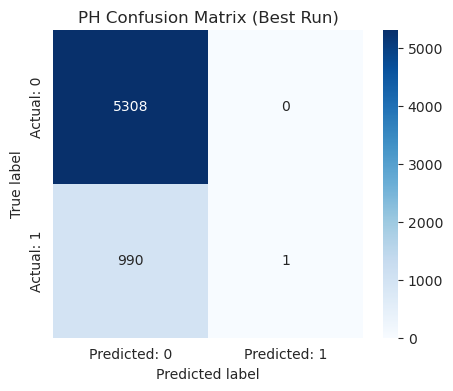

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

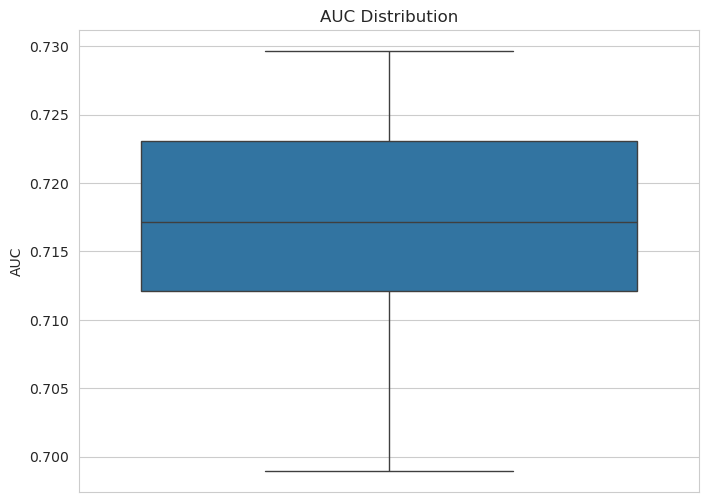

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

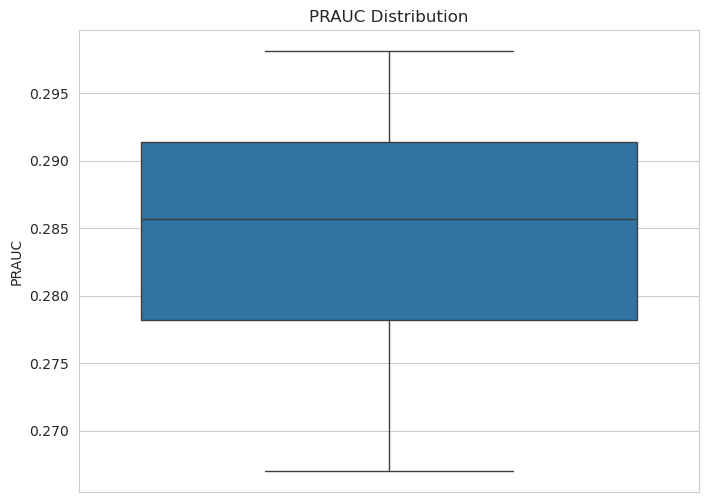

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

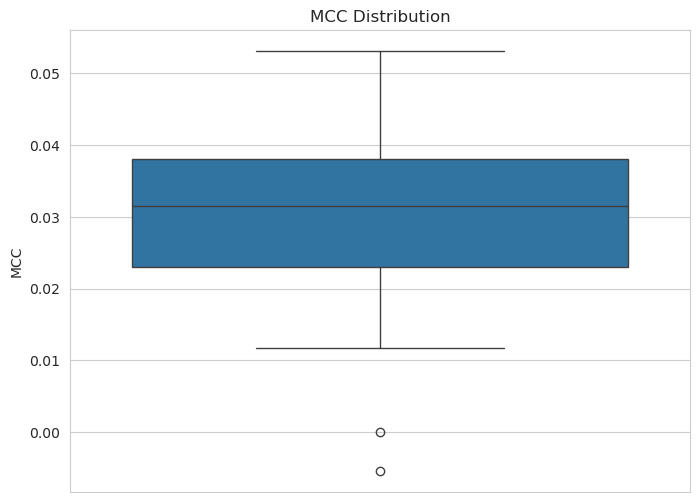

In [21]:
ph_results, y_test, y_pred, X_test = clf.evaluate_model(model, X, y, runs=30, test_size=0.2, subset_name='PH', save_path=None, cmap="Blues")

In [22]:
# Build predicted dataset for PH 
df_pred_ph = X_test.copy()

df_pred_ph['residue_str'] = df_pred_ph['residue_name'].map(reverse_residue)
df_pred_ph['type_str']    = df_pred_ph['type'].map(reverse_type)
df_pred_ph['IBS_pred']    = y_pred
df_pred_ph['exposed']     = X_test['exposed']

df_pred_ph.to_csv("/home/user_stel/AISB/Project/dataset/predicted /PH_pred.csv", index=False)

## PLA

In [23]:
path_to_pla = '/home/user_stel/AISB/Project/dataset/PLA_subset.csv'
pla_df = clf.load_data(path_to_pla)

columns_to_remove = ['domain', 'residue_number']
X, y = clf.separate_features_target(pla_df, target='IBS', columns_to_remove=columns_to_remove)

[Run 1] AUC: 0.7248, PR AUC: 0.4695, MCC: 0.1891
  ↳ New best model (AUC=0.7248)
[Run 2] AUC: 0.7203, PR AUC: 0.4737, MCC: 0.2148
[Run 3] AUC: 0.7259, PR AUC: 0.4811, MCC: 0.2243
  ↳ New best model (AUC=0.7259)
[Run 4] AUC: 0.7281, PR AUC: 0.4720, MCC: 0.1748
  ↳ New best model (AUC=0.7281)
[Run 5] AUC: 0.7191, PR AUC: 0.4750, MCC: 0.2094
[Run 6] AUC: 0.7111, PR AUC: 0.4605, MCC: 0.1973
[Run 7] AUC: 0.7269, PR AUC: 0.4908, MCC: 0.2306
[Run 8] AUC: 0.7167, PR AUC: 0.4539, MCC: 0.1843
[Run 9] AUC: 0.7271, PR AUC: 0.4751, MCC: 0.1927
[Run 10] AUC: 0.7145, PR AUC: 0.4627, MCC: 0.2089
[Run 11] AUC: 0.7234, PR AUC: 0.4662, MCC: 0.2072
[Run 12] AUC: 0.7181, PR AUC: 0.4643, MCC: 0.1935
[Run 13] AUC: 0.7134, PR AUC: 0.4595, MCC: 0.1937
[Run 14] AUC: 0.7338, PR AUC: 0.4897, MCC: 0.2212
  ↳ New best model (AUC=0.7338)
[Run 15] AUC: 0.7269, PR AUC: 0.4772, MCC: 0.2078
[Run 16] AUC: 0.7218, PR AUC: 0.4556, MCC: 0.1821
[Run 17] AUC: 0.7189, PR AUC: 0.4787, MCC: 0.2160
[Run 18] AUC: 0.7197, PR AUC: 0

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[Run 30] AUC: 0.7099, PR AUC: 0.4583, MCC: 0.1835


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

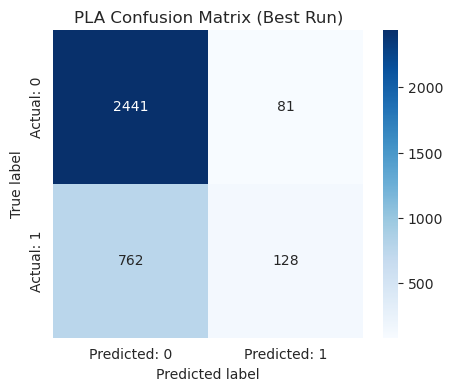

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

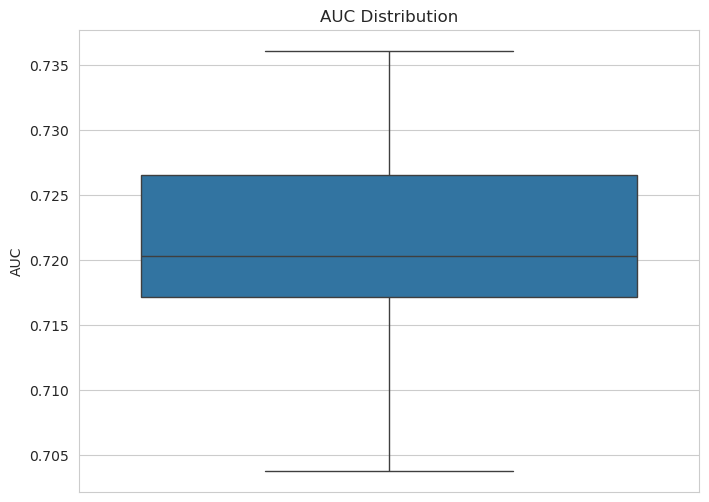

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

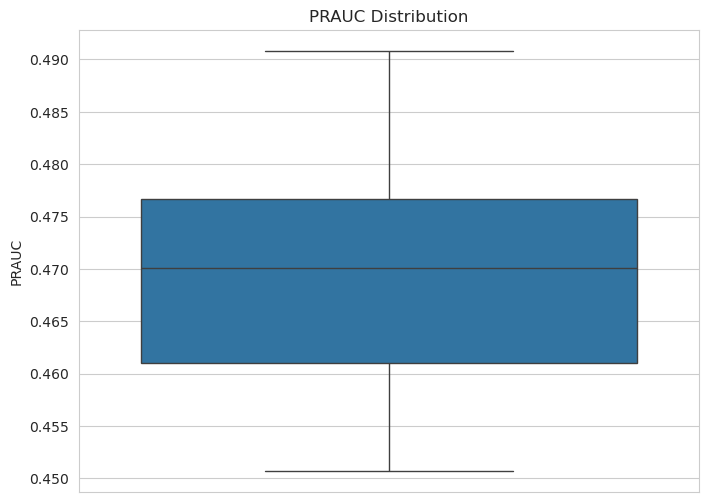

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

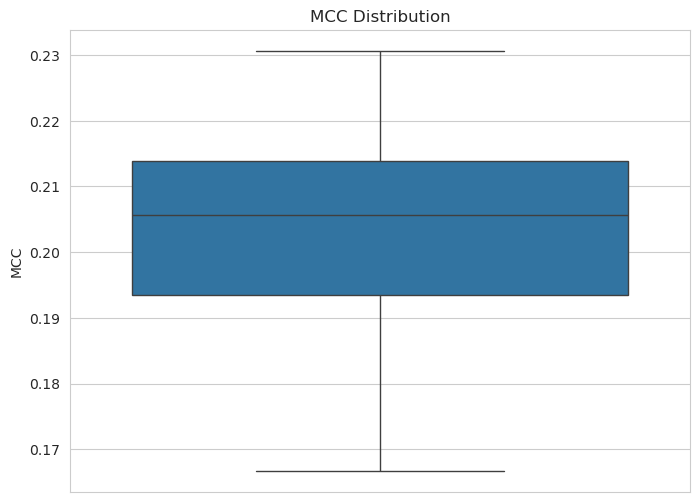

In [24]:
pla_results, y_test, y_pred, X_test = clf.evaluate_model(model, X, y, runs=30, test_size=0.2, subset_name='PLA', save_path=None, cmap="Blues")

In [25]:
# Build predicted dataset for PLA 
df_pred_pla = X_test.copy()

df_pred_pla['residue_str'] = df_pred_pla['residue_name'].map(reverse_residue)
df_pred_pla['type_str']    = df_pred_pla['type'].map(reverse_type)
df_pred_pla['IBS_pred']    = y_pred
df_pred_pla['exposed']     = X_test['exposed']

df_pred_pla.to_csv("/home/user_stel/AISB/Project/dataset/predicted /PLA_pred.csv", index=False)

## PLD

In [26]:
path_to_pld = '/home/user_stel/AISB/Project/dataset/PLD_subset.csv'
pld_df = clf.load_data(path_to_pld)

columns_to_remove = ['domain', 'residue_number']
X, y = clf.separate_features_target(pld_df, target='IBS', columns_to_remove=columns_to_remove)

[Run 1] AUC: 0.6643, PR AUC: 0.2986, MCC: 0.1087
  ↳ New best model (AUC=0.6643)
[Run 2] AUC: 0.6629, PR AUC: 0.2972, MCC: 0.1130
[Run 3] AUC: 0.6648, PR AUC: 0.2876, MCC: 0.0853
  ↳ New best model (AUC=0.6648)
[Run 4] AUC: 0.6758, PR AUC: 0.3082, MCC: 0.0883
  ↳ New best model (AUC=0.6758)
[Run 5] AUC: 0.6766, PR AUC: 0.2925, MCC: 0.0797
  ↳ New best model (AUC=0.6766)
[Run 6] AUC: 0.6810, PR AUC: 0.3102, MCC: 0.1072
  ↳ New best model (AUC=0.6810)
[Run 7] AUC: 0.6733, PR AUC: 0.3003, MCC: 0.1035
[Run 8] AUC: 0.6579, PR AUC: 0.2811, MCC: 0.1073
[Run 9] AUC: 0.6609, PR AUC: 0.2932, MCC: 0.0951
[Run 10] AUC: 0.6598, PR AUC: 0.2851, MCC: 0.1151
[Run 11] AUC: 0.6556, PR AUC: 0.2954, MCC: 0.1021
[Run 12] AUC: 0.6617, PR AUC: 0.2880, MCC: 0.0801
[Run 13] AUC: 0.6759, PR AUC: 0.2943, MCC: 0.0828
[Run 14] AUC: 0.6645, PR AUC: 0.2946, MCC: 0.0927
[Run 15] AUC: 0.6548, PR AUC: 0.2806, MCC: 0.0712
[Run 16] AUC: 0.6618, PR AUC: 0.2886, MCC: 0.0847
[Run 17] AUC: 0.6715, PR AUC: 0.2961, MCC: 0.0583

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[Run 30] AUC: 0.6614, PR AUC: 0.2954, MCC: 0.0859


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

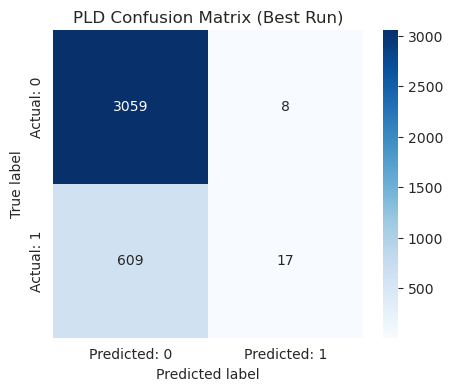

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

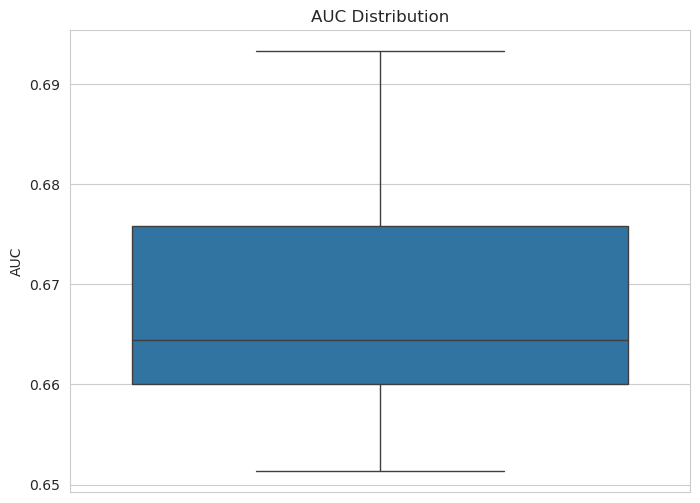

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

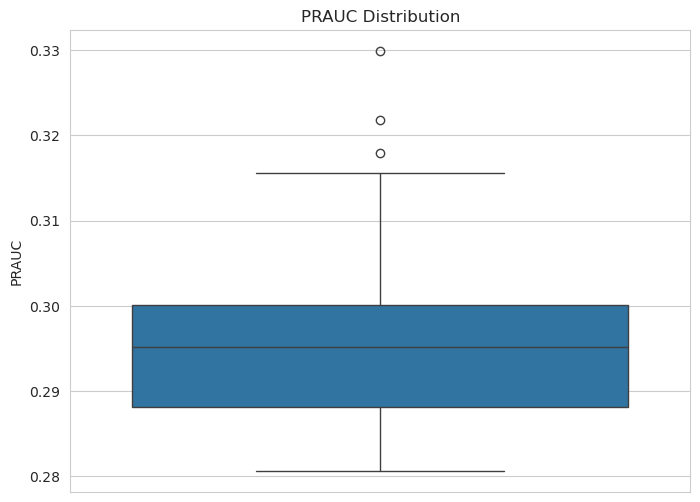

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

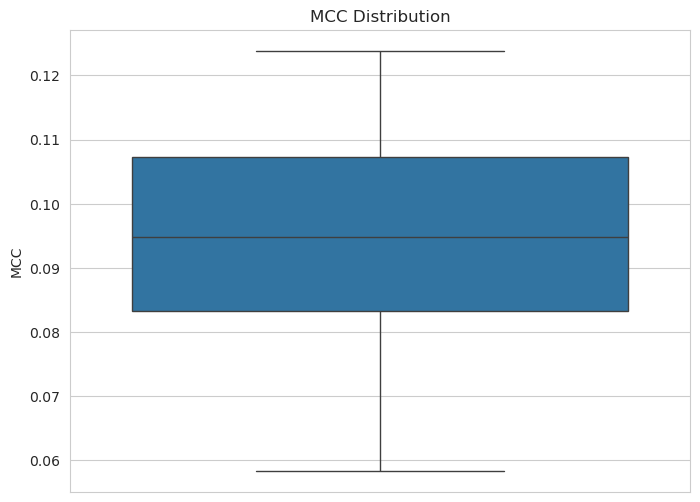

In [27]:
pld_results, y_test, y_pred, X_test = clf.evaluate_model(model, X, y, runs=30, test_size=0.2, subset_name='PLD', save_path=None, cmap="Blues")

In [28]:
# Build predicted dataset for PLD 
df_pred_pld = X_test.copy()

df_pred_pld['residue_str'] = df_pred_pld['residue_name'].map(reverse_residue)
df_pred_pld['type_str']    = df_pred_pld['type'].map(reverse_type)
df_pred_pld['IBS_pred']    = y_pred
df_pred_pld['exposed']     = X_test['exposed']

df_pred_pld.to_csv("/home/user_stel/AISB/Project/dataset/predicted /PLD_pred.csv", index=False)

## PX

In [29]:
path_to_px = '/home/user_stel/AISB/Project/dataset/PX_subset.csv'
px_df = clf.load_data(path_to_px)

columns_to_remove = ['domain', 'residue_number']
X, y = clf.separate_features_target(px_df, target='IBS', columns_to_remove=columns_to_remove)

[Run 1] AUC: 0.6988, PR AUC: 0.3170, MCC: 0.0771
  ↳ New best model (AUC=0.6988)
[Run 2] AUC: 0.7029, PR AUC: 0.3011, MCC: 0.0674
  ↳ New best model (AUC=0.7029)
[Run 3] AUC: 0.6828, PR AUC: 0.3443, MCC: 0.1654
[Run 4] AUC: 0.7022, PR AUC: 0.3232, MCC: 0.1678
[Run 5] AUC: 0.7010, PR AUC: 0.3156, MCC: 0.0843
[Run 6] AUC: 0.7055, PR AUC: 0.3167, MCC: 0.1098
  ↳ New best model (AUC=0.7055)
[Run 7] AUC: 0.6967, PR AUC: 0.3157, MCC: 0.1549
[Run 8] AUC: 0.7045, PR AUC: 0.3232, MCC: 0.0975
[Run 9] AUC: 0.6977, PR AUC: 0.3268, MCC: 0.1395
[Run 10] AUC: 0.6926, PR AUC: 0.3494, MCC: 0.1492
[Run 11] AUC: 0.7085, PR AUC: 0.3234, MCC: 0.1853
  ↳ New best model (AUC=0.7085)
[Run 12] AUC: 0.7047, PR AUC: 0.2941, MCC: 0.0560
[Run 13] AUC: 0.7165, PR AUC: 0.3298, MCC: 0.1239
  ↳ New best model (AUC=0.7165)
[Run 14] AUC: 0.7011, PR AUC: 0.3304, MCC: 0.1010
[Run 15] AUC: 0.7163, PR AUC: 0.3346, MCC: 0.1115
[Run 16] AUC: 0.7217, PR AUC: 0.3627, MCC: 0.1283
  ↳ New best model (AUC=0.7217)
[Run 17] AUC: 0.6

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[Run 30] AUC: 0.7141, PR AUC: 0.3647, MCC: 0.1839


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

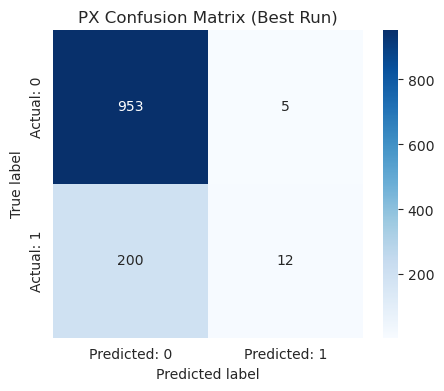

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


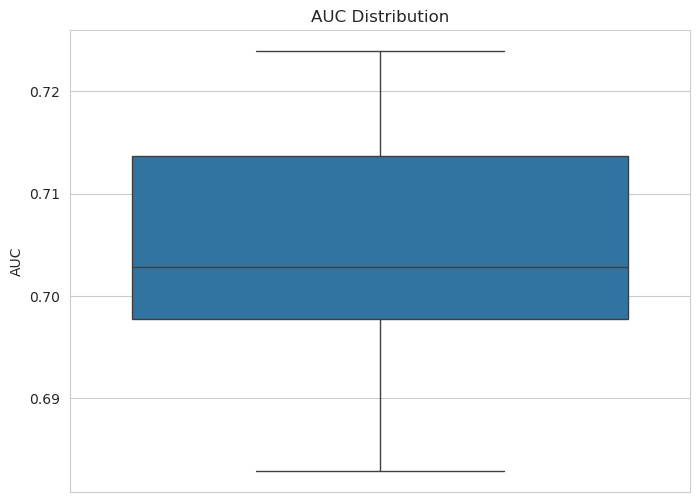

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

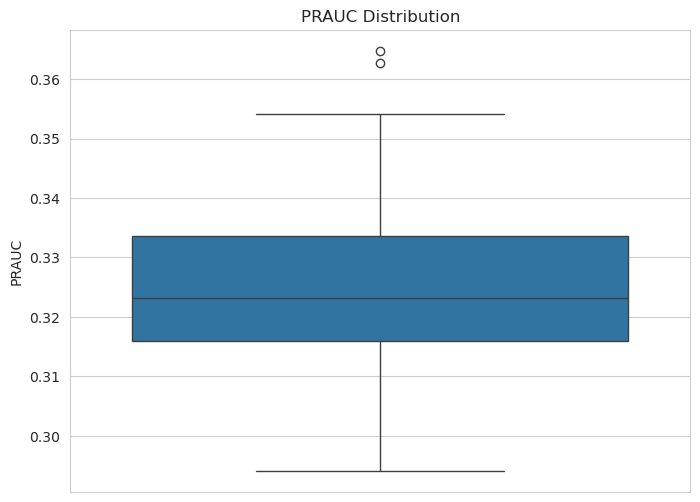

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

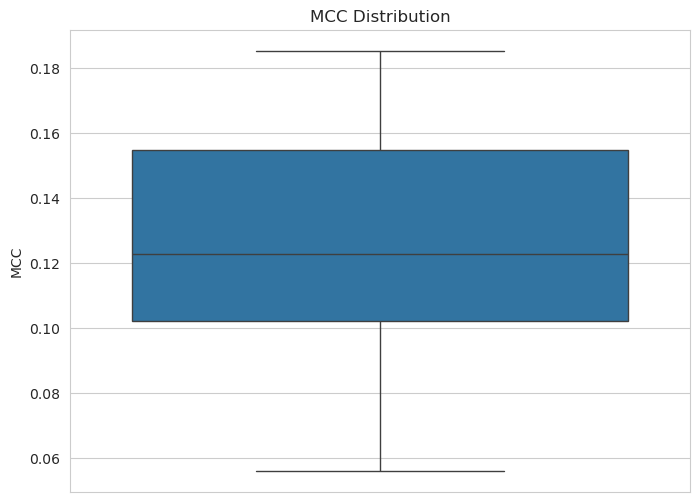

In [30]:
px_results, y_test, y_pred, X_test = clf.evaluate_model(model, X, y, runs=30, test_size=0.2, subset_name='PX', save_path=None, cmap="Blues")

In [31]:
# Build predicted dataset for PX 
df_pred_px = X_test.copy()

df_pred_px['residue_str'] = df_pred_px['residue_name'].map(reverse_residue)
df_pred_px['type_str']    = df_pred_px['type'].map(reverse_type)
df_pred_px['IBS_pred']    = y_pred
df_pred_px['exposed']     = X_test['exposed']

df_pred_px.to_csv("/home/user_stel/AISB/Project/dataset/predicted /PX_pred.csv", index=False)

## START

In [32]:
path_to_start = '/home/user_stel/AISB/Project/dataset/START_subset.csv'
start_df = clf.load_data(path_to_start)

columns_to_remove = ['domain', 'residue_number']
X, y = clf.separate_features_target(start_df, target='IBS', columns_to_remove=columns_to_remove)

[Run 1] AUC: 0.6972, PR AUC: 0.2360, MCC: 0.0875
  ↳ New best model (AUC=0.6972)
[Run 2] AUC: 0.7025, PR AUC: 0.2354, MCC: 0.0820
  ↳ New best model (AUC=0.7025)
[Run 3] AUC: 0.7119, PR AUC: 0.2562, MCC: 0.0997
  ↳ New best model (AUC=0.7119)
[Run 4] AUC: 0.7099, PR AUC: 0.2515, MCC: 0.0879
[Run 5] AUC: 0.7076, PR AUC: 0.2277, MCC: 0.0806
[Run 6] AUC: 0.7004, PR AUC: 0.2361, MCC: 0.0726
[Run 7] AUC: 0.7213, PR AUC: 0.2470, MCC: 0.0671
  ↳ New best model (AUC=0.7213)
[Run 8] AUC: 0.7234, PR AUC: 0.2575, MCC: 0.0905
  ↳ New best model (AUC=0.7234)
[Run 9] AUC: 0.7102, PR AUC: 0.2418, MCC: 0.0752
[Run 10] AUC: 0.7207, PR AUC: 0.2486, MCC: 0.0829
[Run 11] AUC: 0.6986, PR AUC: 0.2409, MCC: 0.0786
[Run 12] AUC: 0.7088, PR AUC: 0.2319, MCC: 0.0383
[Run 13] AUC: 0.7093, PR AUC: 0.2381, MCC: 0.0725
[Run 14] AUC: 0.7287, PR AUC: 0.2557, MCC: 0.0701
  ↳ New best model (AUC=0.7287)
[Run 15] AUC: 0.7161, PR AUC: 0.2566, MCC: 0.0999
[Run 16] AUC: 0.7067, PR AUC: 0.2434, MCC: 0.0605
[Run 17] AUC: 0.7

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[Run 30] AUC: 0.7035, PR AUC: 0.2337, MCC: 0.0923


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


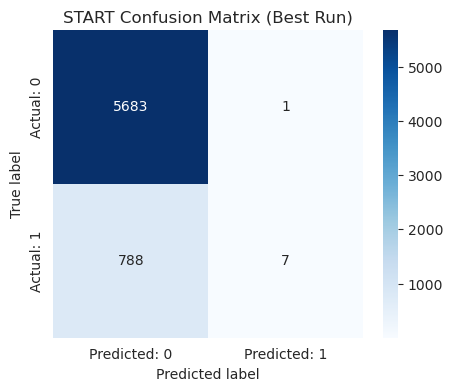

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

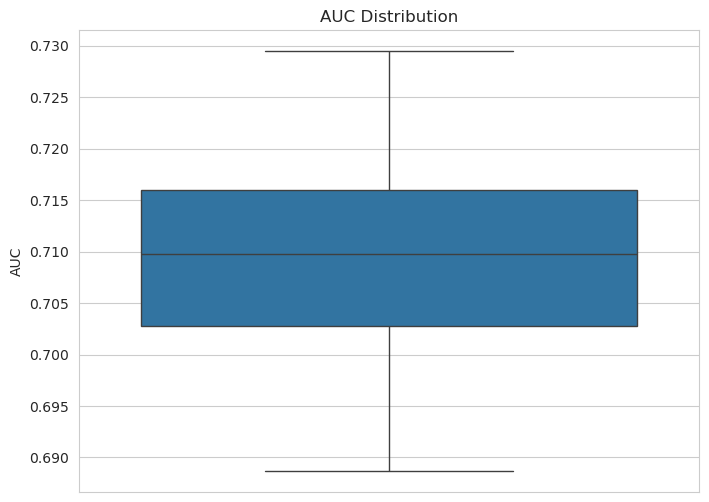

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

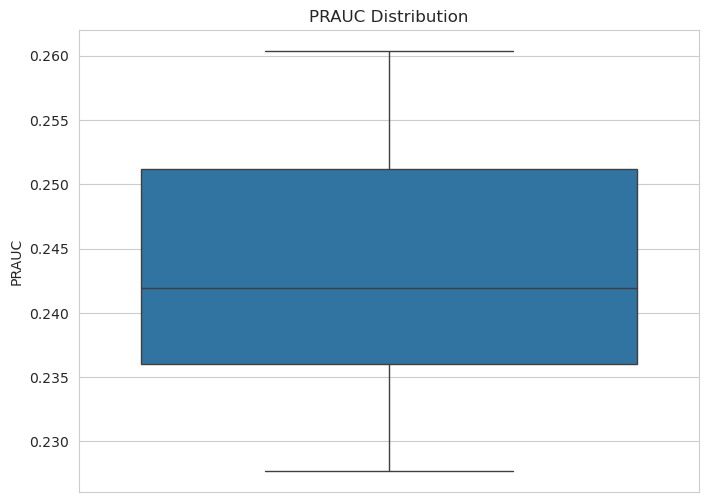

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

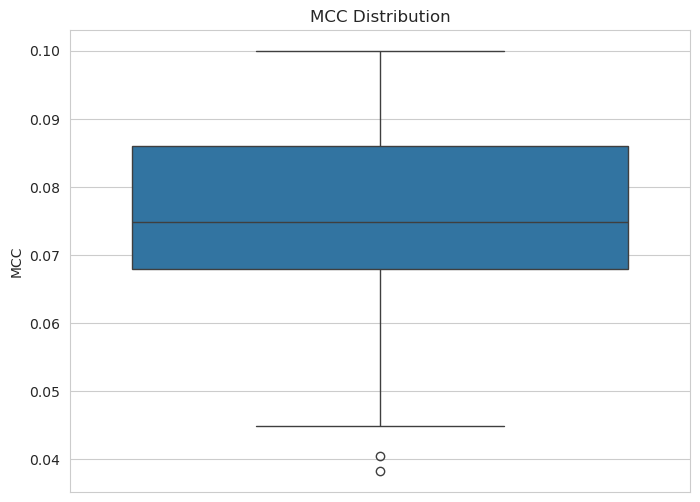

In [33]:
start_results, y_test, y_pred, X_test = clf.evaluate_model(model, X, y, runs=30, test_size=0.2, subset_name='START', save_path=None, cmap="Blues")

In [34]:
# Build predicted dataset for START 
df_pred_start = X_test.copy()

df_pred_start['residue_str'] = df_pred_start['residue_name'].map(reverse_residue)
df_pred_start['type_str']    = df_pred_start['type'].map(reverse_type)
df_pred_start['IBS_pred']    = y_pred
df_pred_start['exposed']     = X_test['exposed']

df_pred_start.to_csv("/home/user_stel/AISB/Project/dataset/predicted /START_pred.csv", index=False)

# Visualization & Figures 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import os

def make_predicted_composition_series(df, label_col, exposed_col, group_col):
    """
    Returns a pd.Series of percent composition of `group_col` within
    rows where label_col==1 and exposed_col==1 (and likewise for label_col==0).
    """
    # IBS Exposed
    s1 = (
        df.query(f"{label_col} == 1 and {exposed_col} == 1")
          [group_col]
          .value_counts(normalize=True)
          * 100
    )
    # non-IBS Exposed
    s0 = (
        df.query(f"{label_col} == 0 and {exposed_col} == 1")
          [group_col]
          .value_counts(normalize=True)
          * 100
    )
    return s1, s0

def plot_figure_8(pred_dict):
    """
    Plots composition figure for multiple predicted DataFrames (one per superfamily).
    pred_dict: dict with keys = superfamily names, values = df_test_pred for each.
    """
    phys_order = [
        "Positive", "Negative", "Polar", "Non-polar",
        "Hydrophobic,H-aromatic", "Hydrophobic,H-non-aromatic"
    ]
    aa_order = [
        "LYS","ARG","ASP","GLU","HIS","ASN","GLN","THR","SER",
        "PRO","ALA","VAL","GLY","TYR","TRP","PHE","LEU","ILE","CYS","MET"
    ]

    # --- Collect reindexed IBS-exposed series for each superfamily ---
    phys_data = {}
    aa_data = {}

    for domain_name, df in pred_dict.items():
        phys_ibs, _ = make_predicted_composition_series(df, 'IBS_pred', 'exposed', 'type_str')
        aa_ibs, _   = make_predicted_composition_series(df, 'IBS_pred', 'exposed', 'residue_str')

        phys_data[domain_name] = phys_ibs.reindex(phys_order, fill_value=0)
        aa_data[domain_name] = aa_ibs.reindex(aa_order, fill_value=0)

    phys_df = pd.DataFrame.from_dict(phys_data, orient="index")
    aa_df   = pd.DataFrame.from_dict(aa_data, orient="index")

    # # Custom display order
    # custom_order = ["ANNEXIN", "C1", "C2", "C2DIS", "PH", "PLA", "PLC/PLD", "PX", "START"]  
    # phys_df = phys_df.loc[custom_order]
    # aa_df   = aa_df.loc[custom_order]


    # --- Plot ---
    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

    def plot_stacked(df, order, color_map, ax, title, legend_title):
        bottom = np.zeros(len(df))
        for category in order:
            ax.barh(df.index, df[category], left=bottom,
                    color=color_map[category], edgecolor='k', linewidth=0.2)
            bottom += df[category].values
        ax.set_xlim(0, 100)
        ax.set_title(title, fontsize=14, weight='bold')
        ax.set_xlabel("Composition (%)")
        handles = [mpatches.Patch(color=color_map[k], label=k) for k in order]
        ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc="upper left", title=legend_title)

    plot_stacked(phys_df[phys_order], phys_order, colorsPerType, axes[0],
                 "A. Physicochemical Composition per Superfamily", "Physicochemical Types")

    plot_stacked(aa_df[aa_order], aa_order, COLORS_taylor, axes[1],
                 "B. Amino Acid Composition per Superfamily", "Amino Acids")

    plt.tight_layout()
    plt.show()

def load_predicted_dfs_from_folder(folder_path):
    pred_dict = {}
    for filename in os.listdir(folder_path):
        if filename.endswith(".csv"):
            domain_name = os.path.splitext(filename)[0]
            df = pd.read_csv(os.path.join(folder_path, filename))
            pred_dict[domain_name] = df
    return pred_dict


In [ ]:
# annexin_IBS, annexin_noIBS = make_predicted_composition_series(df_pred_annexin, label_col='IBS_pred', exposed_col='exposed', group_col='residue_str')
# c1_IBS, c1_noIBS = make_predicted_composition_series(df_pred_c1, label_col='IBS_pred', exposed_col='exposed', group_col='residue_str')
# c2_IBS, c2_noIBS = make_predicted_composition_series(df_pred_c2, label_col='IBS_pred', exposed_col='exposed', group_col='residue_str')
# c2dis_IBS, c2dis_noIBS = make_predicted_composition_series(df_pred_c2dis, label_col='IBS_pred', exposed_col='exposed', group_col='residue_str')
# ph_IBS, ph_noIBS = make_predicted_composition_series(df_pred_ph, label_col='IBS_pred', exposed_col='exposed', group_col='residue_str')
# pla_IBS, pla_noIBS = make_predicted_composition_series(df_pred_pla, label_col='IBS_pred', exposed_col='exposed', group_col='residue_str')
# pld_IBS, pld_noIBS = make_predicted_composition_series(df_pred_pld, label_col='IBS_pred', exposed_col='exposed', group_col='residue_str')
# px_IBS, px_noIBS = make_predicted_composition_series(df_pred_px, label_col='IBS_pred', exposed_col='exposed', group_col='residue_str')
# start_IBS, start_noIBS = make_predicted_composition_series(df_pred_start, label_col='IBS_pred', exposed_col='exposed', group_col='residue_str')

In [46]:
predicted_folder = "/home/user_stel/AISB/Project/dataset/predicted "
predicted_groups = load_predicted_dfs_from_folder(predicted_folder)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

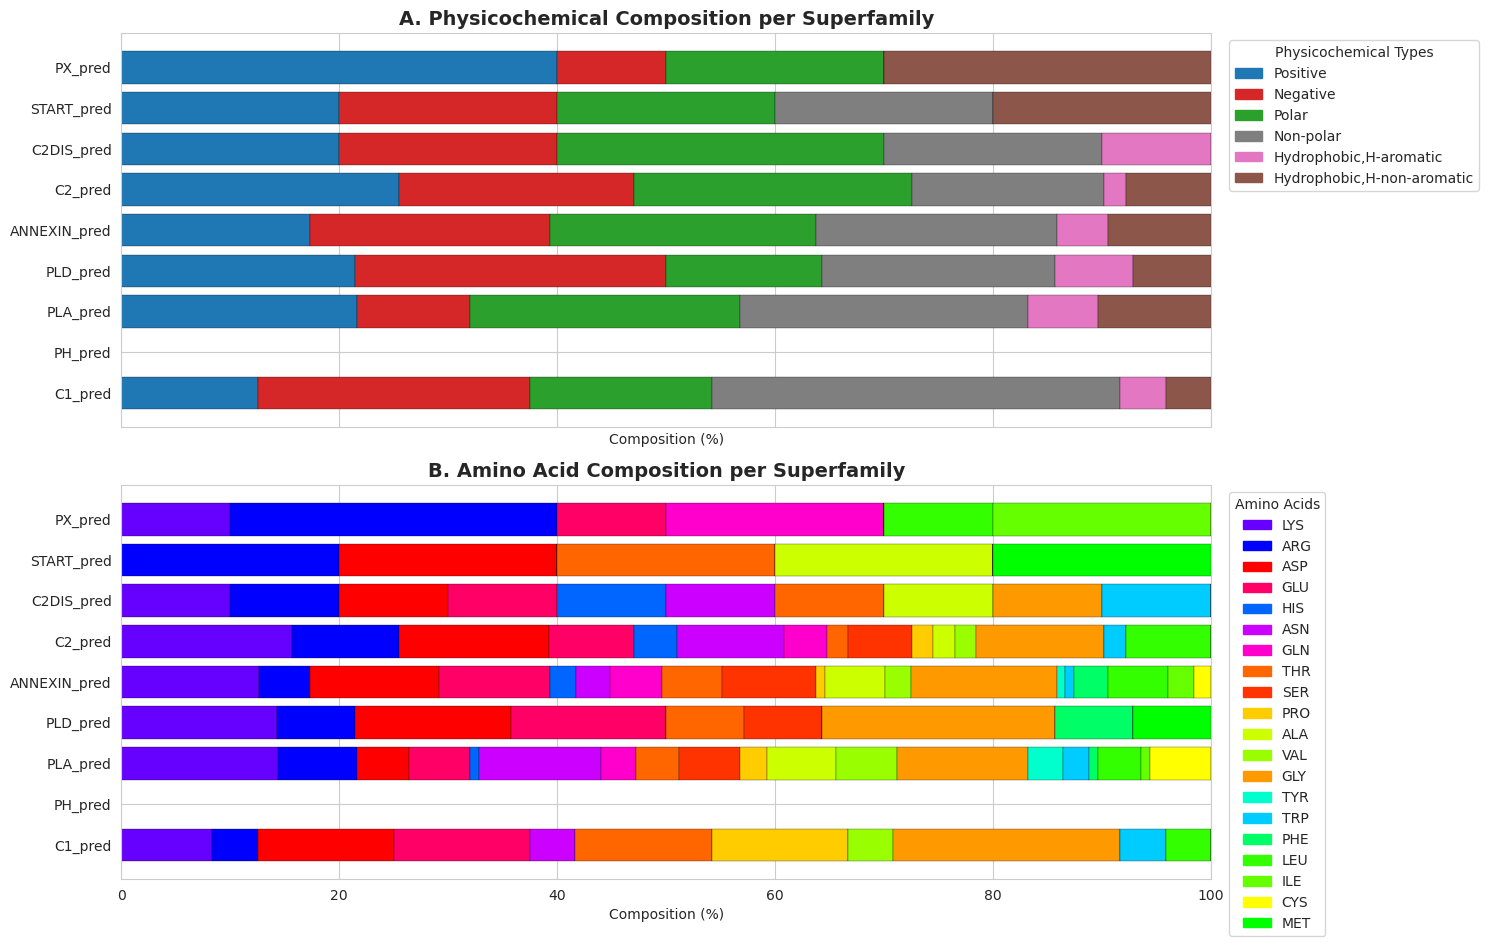

In [47]:
plot_figure_8(predicted_groups)